In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("E:\Data Science\Projects\Customer-Churn-Prediction\customer_churn_data.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HP\AppData\Local\Temp\ipykernel_2704\776376997.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("E:\Data Science\Projects\Customer-Churn-Prediction\customer_churn_data.csv")


,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [3]:
df.shape

(1000, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [5]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [6]:
# Fill the Na values with empty " " because the InternetService col is cateorical col

df['InternetService'] = df['InternetService'].fillna("")

In [7]:
# Check after filling the na values
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [8]:
# To check any duplicate values are present in df
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [10]:
# To check  the corr between the numeric columns 
# Range in between -1 to 1 

numeric_columns_data = df.select_dtypes(include=['number'])
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


# EDA

In [11]:
import matplotlib.pyplot as plt

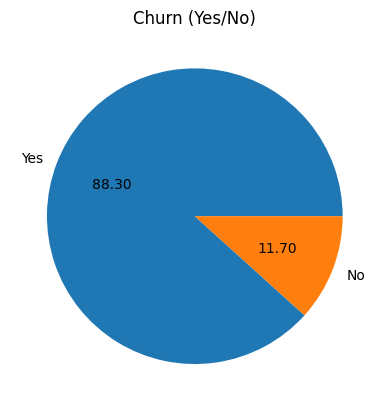

In [12]:
df['Churn'].value_counts().plot(kind='pie',autopct='%.2f')
plt.title("Churn (Yes/No)")
plt.ylabel("")
plt.show()

In [13]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [14]:
df.groupby(['Churn','Gender'])['MonthlyCharges'].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [15]:
df.groupby('Churn')['Tenure'].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [16]:
df.groupby('Churn')['Age'].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

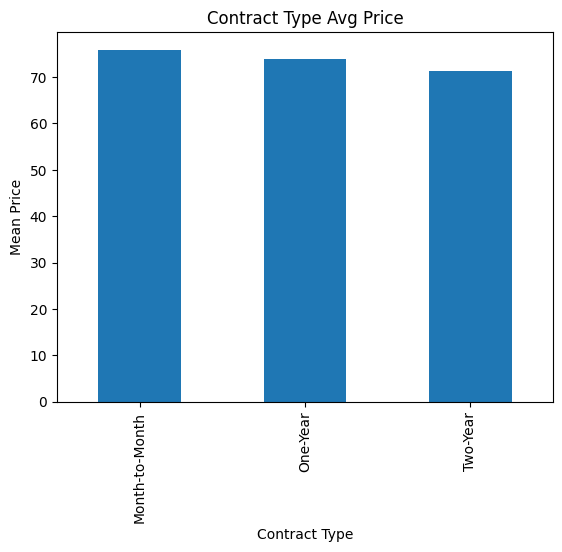

In [17]:
df.groupby('ContractType')['MonthlyCharges'].mean().plot(kind='bar')
plt.ylabel('Mean Price')
plt.xlabel('Contract Type')
plt.title('Contract Type Avg Price')
plt.show()

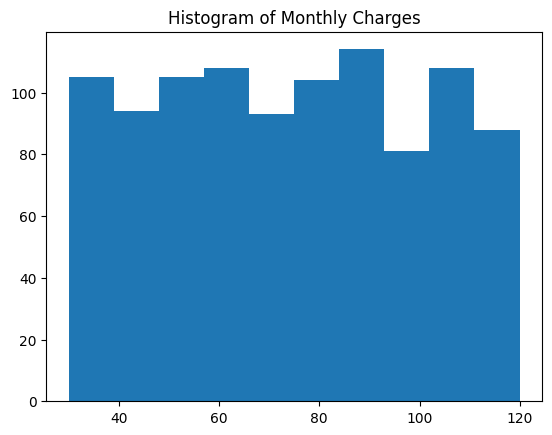

In [18]:
plt.hist(df['MonthlyCharges'])
plt.title("Histogram of Monthly Charges")
plt.show()

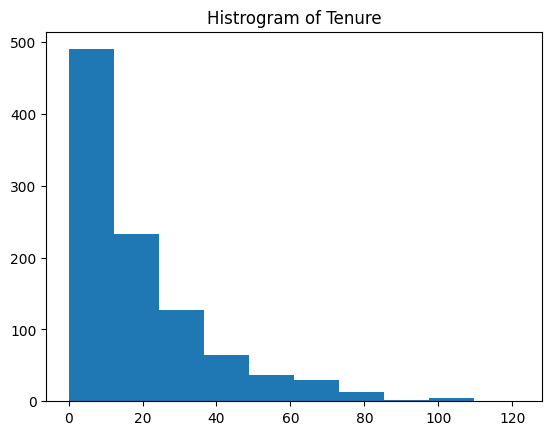

In [19]:
plt.hist(df["Tenure"])
plt.title("Histrogram of Tenure")
plt.show()

In [20]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [34]:
y = df[['Churn']]
X = df[["Age","Gender","Tenure","MonthlyCharges"]]

In [35]:
X  # 0 - Female  1 - Male

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [40]:
y

,Churn
0,1
1,1
2,1
3,1
4,1
...,...
995,1
996,1
997,1
998,1


In [37]:
X["Gender"]=X['Gender'].apply(lambda x: 1 if x=="Female" else 0)

C:\Users\HP\AppData\Local\Temp\ipykernel_2704\996623580.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Gender"]=X['Gender'].apply(lambda x: 1 if x=="Female" else 0)


In [38]:
y.head(2)

,Churn
0,Yes
1,Yes


In [39]:
y["Churn"] = y["Churn"].apply(lambda x:1 if x=="Yes" else 0)

C:\Users\HP\AppData\Local\Temp\ipykernel_2704\111839969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["Churn"] = y["Churn"].apply(lambda x:1 if x=="Yes" else 0)


In [41]:
from sklearn.model_selection import train_test_split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
X_train

,Age,Gender,Tenure,MonthlyCharges
29,42,0,62,97.66
535,45,1,21,102.76
695,41,0,32,49.00
557,40,1,50,114.46
836,60,1,53,89.57
...,...,...,...,...
106,63,0,10,119.90
270,59,1,5,81.69
860,47,0,55,78.63
435,45,1,12,117.13


In [44]:
from sklearn.preprocessing import StandardScaler

In [45]:
scaler = StandardScaler()

In [46]:
X_train = scaler.fit_transform(X_train)

In [47]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [48]:
X_test = scaler.fit_transform(X_test)

In [49]:
X_train

array([[-0.27936177, -1.06725697,  2.28080878,  0.92037124],
       [ 0.02664838,  0.93698147,  0.11295321,  1.12221019],
       [-0.38136516, -1.06725697,  0.69457299, -1.00540975],
       ...,
       [ 0.23065515, -1.06725697,  1.91068709,  0.16723494],
       [ 0.02664838,  0.93698147, -0.36291753,  1.6909211 ],
       [-0.38136516,  0.93698147,  0.06007868, -0.87045469]],
      shape=(800, 4))

In [51]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accurancy score on model is {}".format(accuracy_score(y_test, predictions)))

In [52]:
from sklearn.model_selection import GridSearchCV

Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
lr = LogisticRegression()

In [57]:
import warnings
warnings.filterwarnings("ignore")

In [58]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [60]:
y_pred = lr.predict(X_test)

In [62]:
modelperformance(y_pred)

Accurancy score on model is 0.885


KNN Algorithm

In [63]:
from sklearn.neighbors import KNeighborsClassifier

In [64]:
param_grid = {
    "n_neighbors":[3,5,7,9],
    "weights":["unoform","distance"],
}

In [65]:
gridKn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

In [66]:
gridKn.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['unoform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,7


In [67]:
gridKn.best_params_

{'n_neighbors': 7, 'weights': 'distance'}

In [68]:
y_pred = gridKn.predict(X_test)

In [69]:
modelperformance(y_pred)

Accurancy score on model is 0.865


Support Vector Classifier

In [70]:
from sklearn.svm import SVC

In [71]:
svm = SVC()

In [75]:
param_grid = {
    "C":[0.01,0.1,0.5,1],
    "kernel":["liner","rbf","poly"],
}

In [76]:
gridsvc = GridSearchCV(svm, param_grid, cv=5)

In [77]:
gridsvc.fit(X_train,y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['liner', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [78]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'rbf'}

In [80]:
y_pred = gridsvc.predict(X_test)

In [81]:
modelperformance(y_pred)

Accurancy score on model is 0.885


Decision Tree

In [82]:
from sklearn.tree import DecisionTreeClassifier

In [84]:
dt = DecisionTreeClassifier()

In [90]:
param_grid = {
    "criterion":["gini","entropy"],
    "splitter":["best","random"],
    "max_depth":[None, 10, 20, 30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
}

In [91]:
gridDT = GridSearchCV(dt, param_grid, cv=5)

In [92]:
gridDT.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [93]:
gridDT.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'splitter': 'random'}

In [94]:
y_pred = gridDT.predict(X_test)

In [95]:
modelperformance(y_pred)

Accurancy score on model is 0.855


RandomForest Classifier

In [96]:
from sklearn.ensemble import RandomForestClassifier

In [97]:
rfc = RandomForestClassifier()

In [ ]:
# Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.
param_grid = {
    "n_estimators":[32,64,128,256],
    "max_features":[2,3,4],
    "bootstrap":[True, False]
}

In [99]:
gridRF = GridSearchCV(rfc, param_grid, cv=5)

In [100]:
gridRF.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [32, 64, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,256


In [101]:
y_pred = gridRF.predict(X_test)

In [102]:
modelperformance(y_pred)

Accurancy score on model is 0.865


In [104]:
best_model = gridsvc.best_estimator_

In [105]:
joblib.dump(best_model, "model.pkl")

['model.pkl']